In [ ]:
import numpy as np
import networkx as nx
import pandas as pd

In [ ]:

# --- 1. CONFIGURACIÓN INICIAL Y CARGA DE DATOS ---
file_paths = {
    'Alzheimer': 'matrices/matriz_AD.csv',
    'Control Alzheimer': 'matrices/matriz_CNAD.csv',
    'DCL': 'matrices/matriz_MCI.csv',
    'Control DCL': 'matrices/matriz_CNMCI.csv'
}
try:
    correlation_matrices = {name: pd.read_csv(path, header=0).values for name, path in file_paths.items()}
    print("✅ Matrices loaded successfully from CSV files.")
except FileNotFoundError as e:
    print(f"❌ Error: Could not find the file {e.filename}.")
    exit()

print("\n--- Métricas de Integración y Segregación Funcional ---")
if not correlation_matrices:
    print("No se cargaron matrices de correlación. No se pueden calcular las métricas.")
else:
    # Set a threshold for binarization, e.g., keep the top 10% of connections
    threshold = np.percentile([m for m in correlation_matrices.values()], 90)

    for group_name, matrix in correlation_matrices.items():
        # Binarize the matrix to create an unweighted graph
        adj_matrix = (np.abs(matrix) > threshold).astype(int)
        
        # Create a NetworkX graph
        G = nx.from_numpy_array(adj_matrix)
        G.remove_edges_from(nx.selfloop_edges(G))

        print(f"\nGrupo: {group_name}")

        # Integration Metric 1: Average Path Length
        if nx.is_connected(G):
            avg_path_length = nx.average_shortest_path_length(G)
            print(f"   Longitud de Camino Promedio (Average Path Length): {avg_path_length:.4f}")
        else:
            print("   El grafo no está conectado, no se puede calcular la Longitud de Camino Promedio directamente.")

        # Integration Metric 2: Global Efficiency
        global_efficiency = nx.global_efficiency(G)
        print(f"   Eficiencia Global (Global Efficiency): {global_efficiency:.4f}")

        # Segregation Metric 3: Average Clustering Coefficient
        avg_clustering_coefficient = nx.average_clustering(G)
        print(f"   Coeficiente de Agrupamiento Promedio (Average Clustering Coefficient): {avg_clustering_coefficient:.4f}")

        # --- Otras métricas a considerar: ---
        # Note: Centrality metrics are usually calculated per node; we'll report the average.
        # ------------------------------------

        # Integration: Betweenness Centrality (Promedio)
        betweenness_centrality = nx.betweenness_centrality(G)
        avg_betweenness = np.mean(list(betweenness_centrality.values()))
        print(f"   Centralidad de Intermediación Promedio (Average Betweenness Centrality): {avg_betweenness:.4f}")

        # Integration: Closeness Centrality (Promedio)
        closeness_centrality = nx.closeness_centrality(G)
        avg_closeness = np.mean(list(closeness_centrality.values()))
        print(f"   Centralidad de Cercanía Promedio (Average Closeness Centrality): {avg_closeness:.4f}")

        # Segregation: Modularity
        # Requires community detection; we'll use a standard algorithm
        try:
            communities = nx.community.greedy_modularity_communities(G)
            modularity = nx.community.modularity(G, communities)
            print(f"   Modularidad (Modularity): {modularity:.4f}")
        except:
            print("   No se pudo calcular la Modularidad. (Grafo demasiado pequeño o desconectado)")

        # Segregation: Transitivity
        transitivity = nx.transitivity(G)
        print(f"   Transitividad (Transitivity): {transitivity:.4f}")

print("\n🎉 ¡Cálculo de métricas completado!")

✅ Matrices loaded successfully from CSV files.

--- Métricas de Integración y Segregación Funcional ---

Grupo: Alzheimer
   Longitud de Camino Promedio (Average Path Length): 2.4811
   Eficiencia Global (Global Efficiency): 0.4641
   Coeficiente de Agrupamiento Promedio (Average Clustering Coefficient): 0.5445
   Centralidad de Intermediación Promedio (Average Betweenness Centrality): 0.0050
   Centralidad de Cercanía Promedio (Average Closeness Centrality): 0.4156
   Modularidad (Modularity): 0.3753
   Transitividad (Transitivity): 0.4441

Grupo: Control Alzheimer
   El grafo no está conectado, no se puede calcular la Longitud de Camino Promedio directamente.
   Eficiencia Global (Global Efficiency): 0.5653
   Coeficiente de Agrupamiento Promedio (Average Clustering Coefficient): 0.6003
   Centralidad de Intermediación Promedio (Average Betweenness Centrality): 0.0032
   Centralidad de Cercanía Promedio (Average Closeness Centrality): 0.5156
   Modularidad (Modularity): 0.2264
   Tra

In [12]:
import matplotlib.pyplot as plt
from math import pi

# Assume 'correlation_matrices' is already loaded from your previous script.
# Define the metrics you want to plot
metrics_to_plot = {
    'Avg Path Length': [],
    'Global Efficiency': [],
    'Avg Clustering Coefficient': [],
    'Avg Betweenness Centrality': [],
    'Avg Closeness Centrality': [],
    'Modularity': [],
    'Transitivity': []
}

group_names = list(correlation_matrices.keys())
threshold = 0.5 # Example threshold, use your chosen value

# Loop through each group to calculate metrics and store them
for group_name, matrix in correlation_matrices.items():
    adj_matrix = (np.abs(matrix) > threshold).astype(int)
    G = nx.from_numpy_array(adj_matrix)
    G.remove_edges_from(nx.selfloop_edges(G))

    # Calculate metrics
    if nx.is_connected(G):
        avg_path_length = nx.average_shortest_path_length(G)
    else:
        avg_path_length = np.nan # Use NaN for unconnected graphs

    global_efficiency = nx.global_efficiency(G)
    avg_clustering_coefficient = nx.average_clustering(G)
    avg_betweenness = np.mean(list(nx.betweenness_centrality(G).values()))
    avg_closeness = np.mean(list(nx.closeness_centrality(G).values()))

    try:
        communities = nx.community.greedy_modularity_communities(G)
        modularity = nx.community.modularity(G, communities)
    except:
        modularity = np.nan

    transitivity = nx.transitivity(G)

    # Store metrics
    metrics_to_plot['Avg Path Length'].append(avg_path_length)
    metrics_to_plot['Global Efficiency'].append(global_efficiency)
    metrics_to_plot['Avg Clustering Coefficient'].append(avg_clustering_coefficient)
    metrics_to_plot['Avg Betweenness Centrality'].append(avg_betweenness)
    metrics_to_plot['Avg Closeness Centrality'].append(avg_closeness)
    metrics_to_plot['Modularity'].append(modularity)
    metrics_to_plot['Transitivity'].append(transitivity)

# Create a DataFrame for easy plotting
df_metrics = pd.DataFrame(metrics_to_plot, index=group_names)
print(df_metrics)

                   Avg Path Length  Global Efficiency  \
Alzheimer                      NaN           0.036584   
Control Alzheimer              NaN           0.066286   
DCL                            NaN           0.059585   
Control DCL                    NaN           0.008120   

                   Avg Clustering Coefficient  Avg Betweenness Centrality  \
Alzheimer                            0.184355                    0.002648   
Control Alzheimer                    0.276330                    0.005763   
DCL                                  0.268058                    0.007094   
Control DCL                          0.094222                    0.000288   

                   Avg Closeness Centrality  Modularity  Transitivity  
Alzheimer                          0.026988    0.834393      0.392719  
Control Alzheimer                  0.048067    0.797741      0.464335  
DCL                                0.040374    0.811439      0.440958  
Control DCL                        0.005

## Bar Chart for Comparison

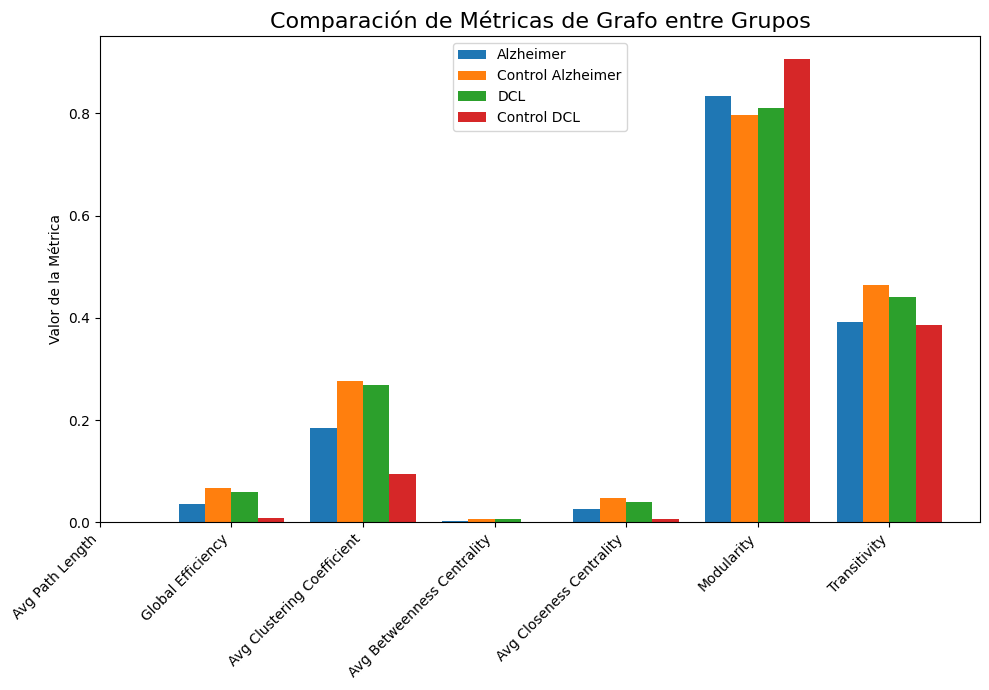

In [13]:
# Create a grouped bar chart for all metrics
metrics_names = list(df_metrics.columns)
num_metrics = len(metrics_names)
num_groups = len(group_names)
bar_width = 0.2

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(num_metrics)

for i in range(num_groups):
    group_values = df_metrics.iloc[i].values
    ax.bar(x + i * bar_width, group_values, bar_width, label=group_names[i])

ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparación de Métricas de Grafo entre Grupos', fontsize=16)
ax.set_xticks(x + bar_width * (num_groups - 1) / 2)
ax.set_xticklabels(metrics_names, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Spider Chart - REVISAR


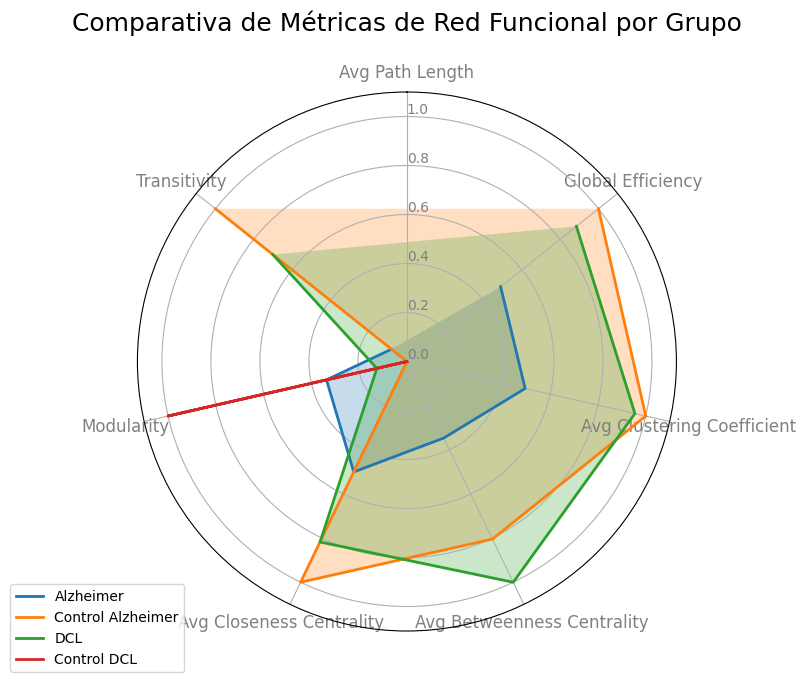

In [14]:
# 2. Manejo de valores NaN y normalización de los datos
# Remplazamos los valores NaN con 0 para que la normalización funcione correctamente
df_filled = df_metrics.fillna(0)
# Normalizamos cada columna a una escala de 0 a 1
df_normalized = (df_filled - df_filled.min()) / (df_filled.max() - df_filled.min())

# 3. Preparación de los datos para el ploteo
categories = list(df_normalized.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Cierra el círculo
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Colores para cada línea

# 4. Configuración del gráfico de radar (spider chart)
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.set_rlabel_position(0)
plt.yticks(np.arange(0, 1.1, 0.2), ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.1)

# 5. Iterar sobre cada grupo y trazar su perfil en el gráfico
for i, group in enumerate(df_metrics.index):
    values = df_normalized.loc[group].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=group, color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.25)

# 6. Añadir títulos y leyenda para una mejor visualización
plt.title('Comparativa de Métricas de Red Funcional por Grupo', size=18, color='black', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# 7. Mostrar el gráfico
plt.show()